# 8.7. Densely Connected Networks (DenseNet)

In [14]:
import pandas as pd
import torch
from torch import nn
from d2l import torch as d2l
from torchinfo import summary

## 8.7.2. Dense Blocks

In [2]:
def conv_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=3, padding=1))

In [3]:
class DenseBlock(nn.Module):
    def __init__(self, num_convs, num_channels):
        super(DenseBlock, self).__init__()
        layer = []
        for i in range(num_convs):
            layer.append(conv_block(num_channels))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            # Concatenate input and output of each block along the channels
            X = torch.cat((X, Y), dim=1)
        return X

In [4]:
blk = DenseBlock(2, 10)
X = torch.randn(4, 3, 8, 8)
Y = blk(X)
Y.shape

torch.Size([4, 23, 8, 8])

## 8.7.3. Transition Layers


In [5]:
def transition_block(num_channels):
    return nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.LazyConv2d(num_channels, kernel_size=1),
        nn.AvgPool2d(kernel_size=2, stride=2))

In [6]:
blk = transition_block(10)
blk(Y).shape

torch.Size([4, 10, 4, 4])

## 8.7.4. DenseNet Model

In [7]:
class DenseNet(d2l.Classifier):
    def b1(self):
        return nn.Sequential(
            nn.LazyConv2d(64, kernel_size=7, stride=2, padding=3),
            nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1))

In [8]:
@d2l.add_to_class(DenseNet)
def __init__(self, num_channels=64, growth_rate=32, arch=(4, 4, 4, 4),
             lr=0.1, num_classes=10):
    super(DenseNet, self).__init__()
    self.save_hyperparameters()
    self.net = nn.Sequential(self.b1())
    for i, num_convs in enumerate(arch):
        self.net.add_module(f'dense_blk{i+1}', DenseBlock(num_convs,
                                                          growth_rate))
        # The number of output channels in the previous dense block
        num_channels += num_convs * growth_rate
        # A transition layer that halves the number of channels is added
        # between the dense blocks
        if i != len(arch) - 1:
            num_channels //= 2
            self.net.add_module(f'tran_blk{i+1}', transition_block(
                num_channels))
    self.net.add_module('last', nn.Sequential(
        nn.LazyBatchNorm2d(), nn.ReLU(),
        nn.AdaptiveAvgPool2d((1, 1)), nn.Flatten(),
        nn.LazyLinear(num_classes)))
    self.net.apply(d2l.init_cnn)

## 8.7.5. Training

In [10]:
model = DenseNet(lr=0.01)
summary(model, (128, 1, 96, 96))

Layer (type:depth-idx)                        Output Shape              Param #
DenseNet                                      [128, 10]                 --
├─Sequential: 1-1                             [128, 10]                 --
│    └─Sequential: 2-1                        [128, 64, 24, 24]         --
│    │    └─Conv2d: 3-1                       [128, 64, 48, 48]         3,200
│    │    └─BatchNorm2d: 3-2                  [128, 64, 48, 48]         128
│    │    └─ReLU: 3-3                         [128, 64, 48, 48]         --
│    │    └─MaxPool2d: 3-4                    [128, 64, 24, 24]         --
│    └─DenseBlock: 2-2                        [128, 192, 24, 24]        --
│    │    └─Sequential: 3-5                   --                        130,048
│    └─Sequential: 2-3                        [128, 96, 12, 12]         --
│    │    └─BatchNorm2d: 3-6                  [128, 192, 24, 24]        384
│    │    └─ReLU: 3-7                         [128, 192, 24, 24]        --
│    │    

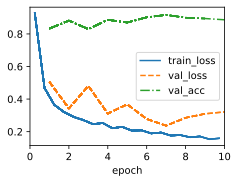

In [11]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128, resize=(96, 96))
trainer.fit(model, data)

## 8.7.7. Exercises

#### 1. Why do we use average pooling rather than max-pooling in the transition layer?

##### It preserves information from all feature maps withing a block, aligning with the feature reuse by concatenation. Max-pooling would introduce a selection bias, where only the maximum values stay. 

## 5. 
#### Design an MLP-based model by applying the DenseNet idea. Apply it to the housing price prediction task in Section 5.7.

### 5.1. Data Upload & Preprocessing

In [12]:
class KaggleHouse(d2l.DataModule):
    def __init__(self, batch_size, train=None, val=None):
        super().__init__()
        self.save_hyperparameters()
        if self.train is None:
            self.raw_train = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_train.csv', self.root,
                sha1_hash='585e9cc93e70b39160e7921475f9bcd7d31219ce'))
            self.raw_val = pd.read_csv(d2l.download(
                d2l.DATA_URL + 'kaggle_house_pred_test.csv', self.root,
                sha1_hash='fa19780a7b011d9b009e8bff8e99922a8ee2eb90'))

In [142]:
data = KaggleHouse(batch_size=64)
print(data.raw_train.shape)
print(data.raw_val.shape)

(1460, 81)
(1459, 80)


In [143]:
print(data.raw_train.iloc[:4, [0, 1, 2, 3, -3, -2, -1]])

   Id  MSSubClass MSZoning  LotFrontage SaleType SaleCondition  SalePrice
0   1          60       RL         65.0       WD        Normal     208500
1   2          20       RL         80.0       WD        Normal     181500
2   3          60       RL         68.0       WD        Normal     223500
3   4          70       RL         60.0       WD       Abnorml     140000


In [144]:
data.raw_train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [145]:
@d2l.add_to_class(KaggleHouse)
def preprocess(self):
    # Remove the ID and label columns
    label = 'SalePrice'
    features = pd.concat(
        (self.raw_train.drop(columns=['Id', label]),
         self.raw_val.drop(columns=['Id'])))
    # Standardize numerical columns
    numeric_features = features.dtypes[features.dtypes!='object'].index
    features[numeric_features] = features[numeric_features].apply(
        lambda x: (x - x.mean()) / (x.std()))
    # Replace NAN numerical features by 0
    features[numeric_features] = features[numeric_features].fillna(0)
    # Replace discrete features by one-hot encoding
    features = pd.get_dummies(features, dummy_na=True)
    # Save preprocessed features
    self.train = features[:self.raw_train.shape[0]].copy()
    self.train[label] = self.raw_train[label]
    self.val = features[self.raw_train.shape[0]:].copy()

In [146]:
data.preprocess()
data.train.shape, data.val.shape

((1460, 331), (1459, 330))

In [147]:
data.train.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_WD,SaleType_nan,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_nan,SalePrice
0,0.067320,-0.184443,-0.217841,0.646073,-0.507197,1.046078,0.896679,0.523038,0.580708,-0.29303,...,True,False,False,False,False,False,True,False,False,208500
1,-0.873466,0.458096,-0.072032,-0.063174,2.187904,0.154737,-0.395536,-0.569893,1.177709,-0.29303,...,True,False,False,False,False,False,True,False,False,181500
2,0.067320,-0.055935,0.137173,0.646073,-0.507197,0.980053,0.848819,0.333448,0.097840,-0.29303,...,True,False,False,False,False,False,True,False,False,223500
3,0.302516,-0.398622,-0.078371,0.646073,-0.507197,-1.859033,-0.682695,-0.569893,-0.494771,-0.29303,...,True,False,True,False,False,False,False,False,False,140000
4,0.067320,0.629439,0.518814,1.355319,-0.507197,0.947040,0.753100,1.381770,0.468770,-0.29303,...,True,False,False,False,False,False,True,False,False,250000


In [148]:
data.val.head()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_Oth,SaleType_WD,SaleType_nan,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,SaleCondition_nan
0,-0.873466,0.458096,0.184340,-0.772420,0.391170,-0.340452,-1.113434,-0.569893,0.058332,0.558006,...,False,True,False,False,False,False,False,True,False,False
1,-0.873466,0.500932,0.519702,-0.063174,0.391170,-0.439490,-1.257014,0.032335,1.056991,-0.293030,...,False,True,False,False,False,False,False,True,False,False
2,0.067320,0.201080,0.464294,-0.772420,-0.507197,0.848003,0.657380,-0.569893,0.767271,-0.293030,...,False,True,False,False,False,False,False,True,False,False
3,0.067320,0.372424,-0.024105,-0.063174,0.391170,0.881015,0.657380,-0.458369,0.352443,-0.293030,...,False,True,False,False,False,False,False,True,False,False
4,1.478499,-1.126832,-0.654636,1.355319,-0.507197,0.682939,0.370221,-0.569893,-0.391613,-0.293030,...,False,True,False,False,False,False,False,True,False,False


### 5.2. Error Measure

In [149]:
@d2l.add_to_class(KaggleHouse)
def get_dataloader(self, train):
    label = 'SalePrice'
    data = self.train if train else self.val
    if label not in data: return
    get_tensor = lambda x: torch.tensor(x.values.astype(float),
                                      dtype=torch.float32)
    # Logarithm of prices
    tensors = (get_tensor(data.drop(columns=[label])),  # X
               torch.log(get_tensor(data[label])).reshape((-1, 1)))  # Y
    return self.get_tensorloader(tensors, train)

In [150]:
X_test, Y_test = next(iter(data.get_dataloader(True)))
X_test.shape, Y_test.shape

(torch.Size([64, 330]), torch.Size([64, 1]))

### 5.3. Model

In [56]:
def mlp_block(num_hidden):
    return nn.Sequential(
        nn.LazyBatchNorm1d(), nn.ReLU(),
        nn.LazyLinear(num_hidden))

In [151]:
class DenseBlockMLP(nn.Module):
    def __init__(self, num_linear, num_hidden):
        super(DenseBlockMLP, self).__init__()
        layer = []
        for i in range(num_linear):
            layer.append(mlp_block(num_hidden))
        self.net = nn.Sequential(*layer)

    def forward(self, X):
        for blk in self.net:
            Y = blk(X)
            X = torch.cat((X, Y), dim=1)
        return X

In [152]:
blk = DenseBlockMLP(2, 64)
X = torch.randn(64, 330)
Y = blk(X)
Y.shape

torch.Size([64, 458])

In [153]:
def transition_MLP(num_hidden):
    return nn.Sequential(
        nn.LazyBatchNorm1d(), nn.ReLU(),
        nn.LazyLinear(num_hidden))

In [164]:
class DenseMLP(d2l.Module):
    def __init__(self, num_hidden=330, growth_rate=32, arch=(4, 4, 4, 4), lr=0.05, num_classes=1):
        super(DenseMLP, self).__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(self.b1())
        for i, num_linears in enumerate(arch):
            self.net.add_module(f'dense_mlp{i+1}', DenseBlockMLP(num_linears, growth_rate))
            
            num_hidden += num_linears * growth_rate

            if i != len(arch) - 1:
                num_hidden //= 2
                self.net.add_module(f'trans_mlp{i+1}', transition_MLP(num_hidden))
        self.net.add_module('last', nn.Sequential(
            nn.LazyBatchNorm1d(), nn.ReLU(),
            nn.LazyLinear(num_classes)))    
        
    def b1(self):
        return nn.Sequential(
            nn.LazyLinear(330),
            nn.LazyBatchNorm1d(), nn.ReLU())
        
    def forward(self, X):
        return self.net(X)
        
    def loss(self, y_hat, y):
        fn = nn.MSELoss()
        return fn(y_hat, y)

In [186]:
model2 = DenseMLP(lr=0.05)
model2.to('cpu')
print('sss')

sss


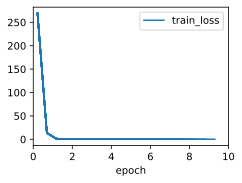

In [187]:
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model2, data)

In [188]:
preds = [model2(torch.tensor(data.val.values.astype(float), dtype=torch.float32))]

In [189]:
ensemble_preds = torch.exp(torch.cat(preds, 1)).mean(1)
ensemble_preds

tensor([165562.6719, 165562.6719, 165562.6719,  ..., 165562.6719,
        165562.6719, 165562.6719], grad_fn=<MeanBackward1>)

In [190]:
submission = pd.DataFrame({'Id':data.raw_val.Id,
                           'SalePrice':ensemble_preds.detach().numpy()})
submission.to_csv('submission.csv', index=False)